# OpenClaw gateway walkthrough

## 代码里对应的位置

- `benchmarks/client-harness/scenarios/docker_single.json` 里把 `client.message` 设成了 `"/context list"`
- `benchmarks/client-harness/src/openclaw_harness/gateway_client.py` 负责连 WebSocket 并发 `chat.send`
- `benchmarks/client-harness/src/openclaw_harness/runner.py` 负责完整调用链：`chat.send -> agent.wait -> chat.history`
- `src/auto-reply/reply/commands-context-report.ts` 负责实现 `/context` 命令

所以 harness 在做的事情，不是“直接调模型 API”，而是“模拟一个 gateway 客户端，通过 OpenClaw 的网关协议发消息”。

In [1]:
from pathlib import Path
import json

repo_root = Path.cwd().resolve()
scenario_path = repo_root / "scenarios" / "docker_single.json"
scenario = json.loads(scenario_path.read_text(encoding="utf-8"))

scenario["client"]

{'role': 'operator',
 'message': '/context list',
 'session_prefix': 'bench-single',
 'session_mode': 'per_worker',
 'history_limit': 20,
 'wait_timeout_ms': 15000,
 'send_timeout_ms': 15000}

上面这个配置里，`message` 就是 harness 要发送的内容。默认值选 `"/context list"`，是因为它不依赖模型密钥，适合做稳定的基准测试。

In [2]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
harness_src = repo_root / "src"
if str(harness_src) not in sys.path:
    sys.path.insert(0, str(harness_src))

from openclaw_harness.gateway_client import GatewayClient
from openclaw_harness.device_identity import load_or_create_device_identity

GatewayClient

openclaw_harness.gateway_client.GatewayClient

## 连接流程

`GatewayClient.connect()` 做了这几步：

1. 用 `websockets.connect(url)` 连到 gateway 的 WebSocket。
2. 等待 gateway 发 `connect.challenge` 事件，里面会带一个 `nonce`。
3. 用本地设备身份对认证 payload 签名。
4. 发送 `connect` 请求，把 token、role、device 信息一起交给 gateway。
5. 连接成功后，再发业务请求，比如 `chat.send`。

这里的设备身份由 `benchmarks/client-harness/.state/device.json` 持久化；如果没有，Python 会调用本机 `node` 生成一对 Ed25519 密钥。

In [3]:
import inspect

print(inspect.getsource(GatewayClient.send_chat))
print("-" * 60)
print(inspect.getsource(GatewayClient.wait_for_agent))
print("-" * 60)
print(inspect.getsource(GatewayClient.load_history))

    async def send_chat(
        self,
        *,
        session_key: str,
        message: str,
        run_id: str,
        timeout_ms: int,
    ) -> GatewayResponse:
        return await self.request(
            "chat.send",
            {
                "sessionKey": session_key,
                "message": message,
                "idempotencyKey": run_id,
                "timeoutMs": timeout_ms,
            },
            timeout_ms=timeout_ms + 5_000,
        )

------------------------------------------------------------
    async def wait_for_agent(self, *, run_id: str, timeout_ms: int) -> GatewayResponse:
        return await self.request(
            "agent.wait",
            {
                "runId": run_id,
                "timeoutMs": timeout_ms,
            },
            timeout_ms=timeout_ms + 5_000,
        )

------------------------------------------------------------
    async def load_history(self, *, session_key: str, limit: int) -> GatewayResponse:
        ret

可以看到，harness 实际发的是 3 个 gateway 方法：

- `chat.send`：把消息送进某个 session
- `agent.wait`：等待这次 run 执行完成
- `chat.history`：把这个 session 的消息历史取回来

而 `"/context list"` 只是 `chat.send` 里的 `message` 字段值。

In [10]:
import asyncio
import os
import shutil
from urllib.error import URLError
from urllib.request import urlopen
from uuid import uuid4


def _candidate_gateway_urls():
    candidates = []
    env_url = os.environ.get("OPENCLAW_GATEWAY_URL", "").strip()
    for url in [env_url, "ws://127.0.0.1:18789", "ws://127.0.0.1:19189"]:
        if url and url not in candidates:
            candidates.append(url)
    return candidates


def _healthcheck_url(ws_url):
    if ws_url.startswith("ws://"):
        return "http://" + ws_url[len("ws://"): ] + "/healthz"
    if ws_url.startswith("wss://"):
        return "https://" + ws_url[len("wss://"): ] + "/healthz"
    raise ValueError(f"Unsupported gateway URL: {ws_url}")


def _probe_gateway_url():
    checks = []
    for url in _candidate_gateway_urls():
        health_url = _healthcheck_url(url)
        try:
            with urlopen(health_url, timeout=2) as response:
                status = getattr(response, "status", None)
                checks.append({"url": url, "health_url": health_url, "result": f"HTTP {status}"})
                if status == 200:
                    return url, checks
        except (URLError, OSError) as exc:
            checks.append({"url": url, "health_url": health_url, "result": f"{type(exc).__name__}: {exc}"})
    return None, checks


async def demo_context_list():
    if shutil.which("node") is None:
        raise RuntimeError(
            "This notebook needs `node` in PATH to create/sign the device identity. "
            "If you are running a Windows Python kernel, switch to a WSL kernel or install Node.js there."
        )

    url, gateway_checks = _probe_gateway_url()
    if url is None:
        checked = "\n".join(f"- {item['health_url']} -> {item['result']}" for item in gateway_checks)
        raise ConnectionError(
            "No reachable OpenClaw gateway was found. "
            "Start one locally or set OPENCLAW_GATEWAY_URL to a reachable WebSocket URL.\n"
            f"Checked:\n{checked}"
        )

    token = os.environ.get("OPENCLAW_GATEWAY_TOKEN", "openclaw-bench-token")
    session_key = os.environ.get("OPENCLAW_SESSION_KEY", "notebook-demo")

    device_identity = load_or_create_device_identity()
    client = GatewayClient(
        url=url,
        token=token,
        role="operator",
        instance_id=f"notebook-{uuid4().hex[:8]}",
        device_identity=device_identity,
    )

    try:
        connect_latency_ms = await client.connect()
        run_id = str(uuid4())

        send_response = await client.send_chat(
            session_key=session_key,
            message="/context list",
            run_id=run_id,
            timeout_ms=15000,
        )
        wait_response = await client.wait_for_agent(run_id=run_id, timeout_ms=15000)
        history_response = await client.load_history(session_key=session_key, limit=20)

        return {
            "gateway_url": url,
            "gateway_checks": gateway_checks,
            "connect_latency_ms": round(connect_latency_ms, 3),
            "send_ok": send_response.ok,
            "send_payload": send_response.payload,
            "wait_ok": wait_response.ok,
            "wait_payload": wait_response.payload,
            "history_ok": history_response.ok,
            "history_message_count": len((history_response.payload or {}).get("messages", []) or []),
            "history_payload": history_response.payload,
        }
    finally:
        await client.close()


# 如果本地已经跑了 gateway，可以取消下面一行注释直接试。
# result = await demo_context_list()
# result

## 为什么说它不是普通 prompt

OpenClaw 内部会先检查消息是不是命令。`/context list` 命中后，会走 `src/auto-reply/reply/commands-context-report.ts` 里的逻辑，生成 context breakdown 文本。

也就是说，语义上更像：

- 客户端发送一条“命令消息”
- gateway / agent 层识别命令
- OpenClaw 自己生成回复
- 最终这段回复再出现在 chat history 里

它不是简单地把 `"/context list"` 四个词原样扔给底层模型。

In [5]:
summary = {
    "message_sent": "/context list",
    "transport": "WebSocket RPC to OpenClaw gateway",
    "methods": ["connect", "chat.send", "agent.wait", "chat.history"],
    "not_a_plain_model_prompt": True,
}

## docker_single 和 docker_multi 是怎么测的

这两个 scenario 都是 Docker runtime，差别主要在 `load` 配置，不在 `message`。换句话说，它们都是发 `/context list`，只是并发模型不同。

In [8]:
from pathlib import Path
import json

base = repo_root / "scenarios"
docker_single = json.loads((base / "docker_single.json").read_text(encoding="utf-8"))
docker_multi = json.loads((base / "docker_multi.json").read_text(encoding="utf-8"))

{
    "docker_single": {
        "message": docker_single["client"]["message"],
        "concurrency": docker_single["load"]["concurrency"],
        "requests_per_worker": docker_single["load"]["requests_per_worker"],
        "worker_stagger_ms": docker_single["load"]["worker_stagger_ms"],
    },
    "docker_multi": {
        "message": docker_multi["client"]["message"],
        "concurrency": docker_multi["load"]["concurrency"],
        "requests_per_worker": docker_multi["load"]["requests_per_worker"],
        "worker_stagger_ms": docker_multi["load"]["worker_stagger_ms"],
    },
}

{'docker_single': {'message': '/context list',
  'concurrency': 1,
  'requests_per_worker': 3,
  'worker_stagger_ms': 0},
 'docker_multi': {'message': '/context list',
  'concurrency': 4,
  'requests_per_worker': 2,
  'worker_stagger_ms': 150}}

可以把它理解成：

- `docker_single`：1 个 worker，同一个 worker 连上 gateway 后连续发 3 次 `/context list`
- `docker_multi`：4 个 worker，每个 worker 发 2 次 `/context list`
- 所以 `docker_single` 总请求数是 `1 * 3 = 3`
- `docker_multi` 总请求数是 `4 * 2 = 8`

这里的“单线程 / 多线程”更准确地说是“单 worker / 多 worker 并发”。代码用的是 `asyncio.create_task(...)` 并发地跑多个 worker，不是 Python `threading.Thread` 去做请求并发。

In [9]:
import inspect
from openclaw_harness.runner import execute_load, resolve_session_key

print(inspect.getsource(resolve_session_key))
print("-" * 60)
print(inspect.getsource(execute_load).split("def build_preflight_payload", 1)[0])

def resolve_session_key(
    *,
    scenario: ScenarioConfig,
    worker_id: int,
    request_index: int,
) -> str:
    prefix = scenario.client.session_prefix
    mode = scenario.client.session_mode
    if mode == "shared":
        return f"{prefix}-shared"
    if mode == "per_request":
        return f"{prefix}-w{worker_id}-r{request_index}"
    return f"{prefix}-w{worker_id}"

------------------------------------------------------------
async def execute_load(
    scenario: ScenarioConfig,
    url: str,
    token: str,
    *,
    device_identity,
) -> list[dict[str, object]]:
    records: list[dict[str, object]] = []

    async def worker(worker_id: int) -> None:
        if scenario.load.worker_stagger_ms > 0:
            await asyncio.sleep((scenario.load.worker_stagger_ms * worker_id) / 1000.0)
        client = GatewayClient(
            url=url,
            token=token,
            role=scenario.client.role,
            instance_id=f"{slugify(scenario.name)}-{worker_id}-{uuid4().

从 `execute_load()` 可以看出 single/multi 的关键差别：

- 它会按 `concurrency` 创建多个 worker task
- 每个 worker 先 `connect()` 一次
- 然后按 `requests_per_worker` 循环发 `chat.send -> agent.wait -> chat.history`
- `worker_stagger_ms` 可以让 worker 错开启动，避免全部在同一毫秒冲进去
- `session_mode=per_worker` 意味着同一个 worker 的多次请求会复用同一个 session key

因为 `docker_single` 和 `docker_multi` 都把 `client.message` 设为 `/context list`，所以它们测的是同一种命令在不同并发下的延迟和资源表现。

## out 目录结构是什么

每次 run 都会生成一个独立目录，形如：

- `benchmarks/client-harness/out/20260319T125032Z_docker-single/`

里面文件多，是因为它不只保存“最终分数”，还保存了：

- 场景实际解析后的配置
- 运行时 / 容器的环境与启动信息
- 原始 collector 输出
- parse 后的 collector summary
- 每一次请求的明细 latency

In [12]:
sample_run = repo_root/ "out" / "20260319T125032Z_docker-single"
sorted(str(path.relative_to(sample_run)) for path in sample_run.rglob("*"))[:40]

['docker_stats.csv',
 'latency.csv',
 'meta.json',
 'runtime',
 'runtime/config',
 'runtime/config/agents',
 'runtime/config/agents/main',
 'runtime/config/agents/main/sessions',
 'runtime/config/agents/main/sessions/be42227d-0e5d-4ad0-951f-35bee0930c1b.jsonl',
 'runtime/config/agents/main/sessions/sessions.json',
 'runtime/config/canvas',
 'runtime/config/canvas/index.html',
 'runtime/config/cron',
 'runtime/config/cron/jobs.json',
 'runtime/config/devices',
 'runtime/config/devices/paired.json',
 'runtime/config/devices/pending.json',
 'runtime/config/openclaw.json',
 'runtime/config/update-check.json',
 'runtime/config/workspace',
 'runtime/docker-logs.txt',
 'runtime/workspace',
 'runtime/workspace/.git',
 'runtime/workspace/.git/HEAD',
 'runtime/workspace/.git/branches',
 'runtime/workspace/.git/config',
 'runtime/workspace/.git/description',
 'runtime/workspace/.git/hooks',
 'runtime/workspace/.git/hooks/applypatch-msg.sample',
 'runtime/workspace/.git/hooks/commit-msg.sample',
 

可以把 `out/<timestamp>_<scenario>/` 里的文件分成几类：

- `scenario.resolved.json`：最终用来跑的 scenario 配置
- `preflight.json`：run 前的可达性 / collector 状态检查
- `latency.csv`：每一次请求的明细记录
- `summary.json`：面向阅读的汇总指标
- `meta.json`：最全面的元数据，包括 runtime、collector、environment 等
- `docker_stats.csv` / `pidstat.log` / `perf_stat.csv` / `perf.data`：collector 原始产物
- `pidstat_*.csv` / `pidstat.summary.json` / `perf_stat.parsed.csv` / `perf_stat.summary.json`：collector parse 后的结果
- `runtime/`：harness 为这次 run 单独准备的 runtime 状态目录

In [13]:
import json

summary_payload = json.loads((sample_run / "summary.json").read_text(encoding="utf-8"))
meta_payload = json.loads((sample_run / "meta.json").read_text(encoding="utf-8"))

{
    "summary_keys": sorted(summary_payload.keys()),
    "collector_names": [c["name"] for c in meta_payload["collectors"]],
    "runtime_keys": sorted(meta_payload["runtime"].keys()),
}

{'summary_keys': ['finished_at',
  'latency_ms',
  'requests_failed',
  'requests_ok',
  'requests_total',
  'scenario',
  'started_at'],
 'collector_names': ['docker_stats', 'pidstat', 'perf_stat', 'perf_record'],
 'runtime_keys': ['container_id',
  'container_name',
  'host_pid',
  'kind',
  'repo_root',
  'runtime_dir',
  'started_by_harness',
  'token',
  'url']}

## 有哪些 metrics

最核心的是 `latency.csv` 和 `summary.json` 里的 latency metrics：

- `connect_latency_ms`：worker 连接 gateway 并完成 `connect` 握手的耗时
- `send_latency_ms`：`chat.send` 这一步的耗时
- `wait_latency_ms`：`agent.wait` 这一步的耗时，通常是最像“业务执行时间”的指标
- `history_latency_ms`：`chat.history` 这一步的耗时
- `total_latency_ms`：一次完整 `send -> wait -> history` 的总耗时
- `history_messages`：这次请求后 session 里有多少条 message
- `success` / `send_status` / `wait_status` / `error`：用来判断是否成功以及失败原因

`summary.json` 会对这些 latency 做聚合，例如 `count / min / max / mean / p50 / p95 / p99`。

collector metrics 则来自额外采样工具：

- `docker_stats.csv`
  - `cpu_percent`
  - `mem_percent`
  - `mem_usage_limit`
  - `net_io`
  - `block_io`
  - `pids`
- `pidstat`
  - CPU: `%usr`, `%system`, `%guest`, `%wait`, `%CPU`
  - Memory: `VSZ`, `RSS`, `%MEM`, major/minor faults
  - IO: `kB_rd/s`, `kB_wr/s`, `kB_ccwr/s`, `iodelay`
- `perf_stat`
  - event counter、runtime、running pct、metric value
- `perf_record`
  - 主要是生成 `perf.data` 供后续 flame graph / hotspot 分析，不是直接给一个简单 latency 数字

如果某个 collector 没有安装或 scenario 关掉了，它会在 `meta.json` 里显示 `skipped`，所以你会看到有些 run 的文件比别的 run 少。

## runtime 目录为什么也有很多文件

对 Docker scenario 来说，harness 不是直接复用你家里的 `~/.openclaw`，而是为每一次 run 在 `runtime/` 下面准备一个隔离的 runtime 环境，包括：

- `runtime/config/openclaw.json`
- `runtime/config/devices/paired.json`
- `runtime/config/devices/pending.json`
- `runtime/workspace/`：容器内使用的 workspace 挂载点
- `runtime/docker-build.log`
- `runtime/docker-logs.txt`

所以 `out/` 下面文件多，本质上是因为这个 harness 在做“可复现 benchmark 证据归档”，而不只是吐一个 QPS 或 latency 数字。

# Results

## 100个context list简单任务

下面这部分专门读取带资源采集器的 100 次大样本场景：

- `docker-single-resource-profile` (`1 x 500`)
- `docker-multi-resource-profile` (`20 x 25`)

这样可以在对比 `send / wait / history / total` 延迟的同时，一起看：

- `docker_stats`：容器 CPU / 内存 / block IO
- `pidstat`：gateway 进程 CPU / RSS / 写入速率 / iodelay
- `iostat`：最忙磁盘设备的 `%util` / `r_await` / `w_await` / `f_await` / `aqu-sz` / `wkb/s`


In [106]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

out_root = Path("/root/client-harness/out")

def find_latest_run_dir(scenario_name: str) -> Path:
    candidates = sorted(
        [path for path in out_root.iterdir() if path.is_dir() and path.name.endswith(f"_{scenario_name}")],
        key=lambda path: path.name,
    )
    if not candidates:
        raise FileNotFoundError(f"No run directory found for scenario: {scenario_name}")
    return candidates[-1]


def load_summary(run_dir: Path) -> dict:
    return json.loads((run_dir / "summary.json").read_text(encoding="utf-8"))


single_100_run_dir = find_latest_run_dir("vps-docker-single-task-00-500-full")
multi_100_run_dir = find_latest_run_dir("vps-docker-multi-task-00-500-full")
single_profile_summary = load_summary(single_100_run_dir)
multi_profile_summary = load_summary(multi_100_run_dir)
# single_profile_summary["scenario"], multi_profile_summary["scenario"]

def nested_get(data: dict, path: list[str], default=None):
    current = data
    for key in path:
        if not isinstance(current, dict) or key not in current:
            return default
        current = current[key]
    return current


def metric_mean(data: dict, path: list[str], default=None):
    metric = nested_get(data, path, None)
    if isinstance(metric, dict):
        return metric.get("mean", default)
    return default


def metric_summary_mean(data: dict, path: list[str], default=None):
    metric = nested_get(data, path, None)
    if isinstance(metric, dict):
        summary = metric.get("summary")
        if isinstance(summary, dict):
            return summary.get("mean", default)
    return default


def build_resource_profile_row(summary: dict) -> dict:
    latency = summary["latency_ms"]
    docker = nested_get(summary, ["collector_analysis", "docker_stats"], {})
    pidstat = nested_get(summary, ["collector_analysis", "pidstat", "sections"], {})
    iostat = nested_get(summary, ["collector_analysis", "iostat"], {})
    iostat_key = nested_get(summary, ["collector_analysis", "iostat", "key_metric_summaries"], {})
    busiest_device = nested_get(summary, ["collector_analysis", "iostat", "key_metrics", "busiest_device"]) or iostat.get("busiest_device_by_util_mean")
    device_metrics = nested_get(iostat, ["devices", busiest_device, "metrics"], {}) if busiest_device else {}
    return {
        "scenario": summary["scenario"],
        "requests_total": summary["requests_total"],
        "requests_ok": summary["requests_ok"],
        "requests_failed": summary["requests_failed"],
        "connect_mean_ms": latency["connect"]["mean"],
        "send_mean_ms": latency["send"]["mean"],
        "send_p95_ms": latency["send"]["p95"],
        "send_p99_ms": latency["send"]["p99"],
        "wait_mean_ms": latency["wait"]["mean"],
        "wait_p50_ms": latency["wait"]["p50"],
        "wait_p95_ms": latency["wait"]["p95"],
        "wait_p99_ms": latency["wait"]["p99"],
        "history_mean_ms": latency["history"]["mean"],
        "history_p95_ms": latency["history"]["p95"],
        "history_p99_ms": latency["history"]["p99"],
        "total_mean_ms": latency["total"]["mean"],
        "total_p50_ms": latency["total"]["p50"],
        "total_p95_ms": latency["total"]["p95"],
        "total_p99_ms": latency["total"]["p99"],
        "docker_cpu_percent_mean": metric_summary_mean(docker, ["metric_summaries", "cpu_percent_value"]),
        "docker_mem_percent_mean": metric_summary_mean(docker, ["metric_summaries", "mem_percent_value"]),
        "docker_block_read_bytes_per_s_mean": metric_summary_mean(docker, ["metric_summaries", "block_read_bytes_per_s"]),
        "docker_block_write_bytes_per_s_mean": metric_summary_mean(docker, ["metric_summaries", "block_write_bytes_per_s"]),
        "pidstat_cpu_percent_mean": metric_summary_mean(pidstat, ["cpu", "metric_summaries", "pct_cpu"]),
        "pidstat_rss_kib_mean": metric_summary_mean(pidstat, ["memory", "metric_summaries", "rss_kib"]),
        "pidstat_kb_wr_per_s_mean": metric_summary_mean(pidstat, ["io", "metric_summaries", "kb_wr_per_s"]),
        "pidstat_iodelay_mean": metric_summary_mean(pidstat, ["io", "metric_summaries", "iodelay"]),
        "iostat_busiest_device": busiest_device,
        "iostat_pct_util_mean": metric_summary_mean(iostat_key, ["pct_util"], metric_mean(device_metrics, ["pct_util"])),
        "iostat_r_await_mean": metric_summary_mean(iostat_key, ["r_await"], metric_mean(device_metrics, ["r_await"])),
        "iostat_w_await_mean": metric_summary_mean(iostat_key, ["w_await"], metric_mean(device_metrics, ["w_await"])),
        "iostat_aqu_sz_mean": metric_summary_mean(iostat_key, ["aqu_sz"], metric_mean(device_metrics, ["aqu_sz"])),
        "iostat_wkb_s_mean": metric_summary_mean(iostat_key, ["wkb_s"], metric_mean(device_metrics, ["wkb_s"])),
    }


resource_profile_df = pd.DataFrame([
    build_resource_profile_row(single_profile_summary),
    build_resource_profile_row(multi_profile_summary),
]).set_index("scenario")

single_100_run_dir, multi_100_run_dir

(PosixPath('/root/client-harness/out/20260324T183523Z_vps-docker-single-task-00-500-full'),
 PosixPath('/root/client-harness/out/20260324T183647Z_vps-docker-multi-task-00-500-full'))

In [107]:
resource_profile_df.round(3).T

scenario,vps-docker-single-task-00-500-full,vps-docker-multi-task-00-500-full
requests_total,500,500
requests_ok,500,500
requests_failed,0,0
connect_mean_ms,67.011,389.055
send_mean_ms,0.72,4.914
send_p95_ms,0.734,11.813
send_p99_ms,4.602,122.814
wait_mean_ms,105.016,1989.45
wait_p50_ms,100.739,1937.666
wait_p95_ms,124.863,3190.944


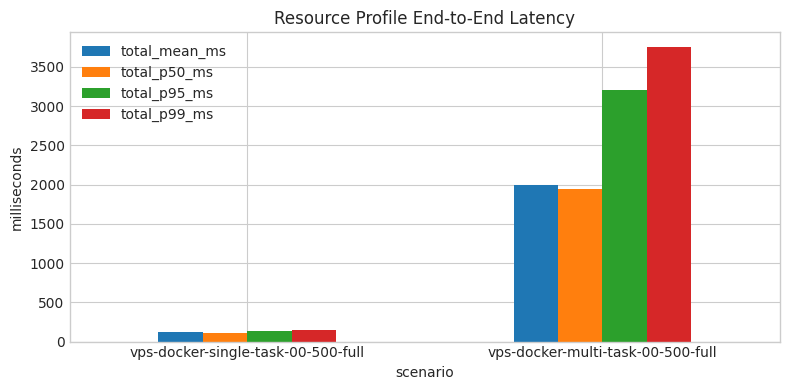

In [108]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 1, figsize=(8, 4))
resource_profile_df[["total_mean_ms", "total_p50_ms", "total_p95_ms", "total_p99_ms"]].plot(
    kind="bar",
    ax=axes,
    rot=0,
    title="Resource Profile End-to-End Latency",
)
axes.set_ylabel("milliseconds")
plt.tight_layout()
plt.show()

                                    connect   send      wait  history  \
scenario                                                                
vps-docker-single-task-00-500-full   67.011  0.720   105.016   12.188   
vps-docker-multi-task-00-500-full   389.055  4.914  1989.450    5.980   

                                       total  
scenario                                      
vps-docker-single-task-00-500-full   117.949  
vps-docker-multi-task-00-500-full   2000.369  


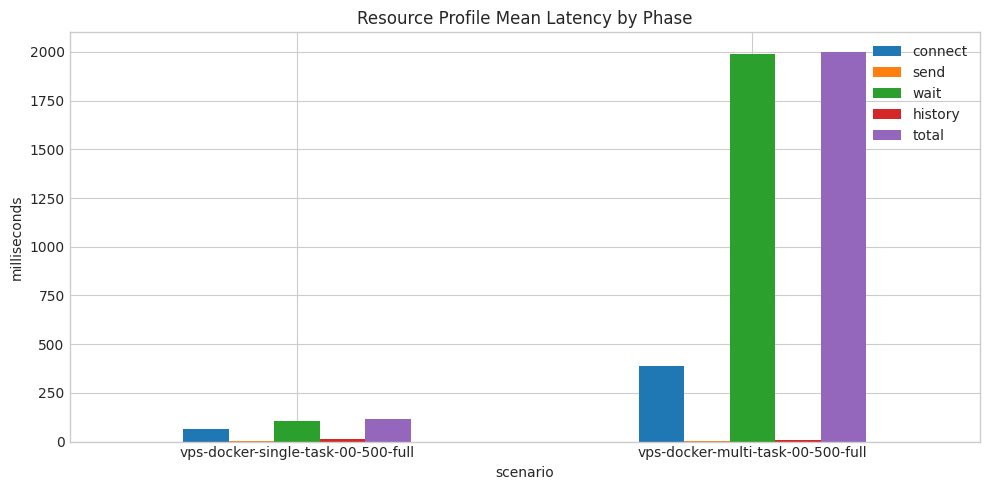

In [109]:
resource_phase_df = resource_profile_df[[
    "connect_mean_ms",
    "send_mean_ms",
    "wait_mean_ms",
    "history_mean_ms",
    "total_mean_ms",
]].rename(columns={
    "connect_mean_ms": "connect",
    "send_mean_ms": "send",
    "wait_mean_ms": "wait",
    "history_mean_ms": "history",
    "total_mean_ms": "total",
})

print(resource_phase_df.round(3))
ax = resource_phase_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Resource Profile Mean Latency by Phase")
ax.set_ylabel("milliseconds")
plt.tight_layout()
plt.show()


                                    send_p95  send_p99  wait_p50  wait_p95  \
scenario                                                                     
vps-docker-single-task-00-500-full     0.734     4.602   100.739   124.863   
vps-docker-multi-task-00-500-full     11.813   122.814  1937.666  3190.944   

                                    wait_p99  history_p95  history_p99  \
scenario                                                                 
vps-docker-single-task-00-500-full   139.965       13.991       15.075   
vps-docker-multi-task-00-500-full   3713.961       10.093       22.291   

                                    total_p95  total_p99  
scenario                                                  
vps-docker-single-task-00-500-full    138.049    149.266  
vps-docker-multi-task-00-500-full    3206.884   3750.755  


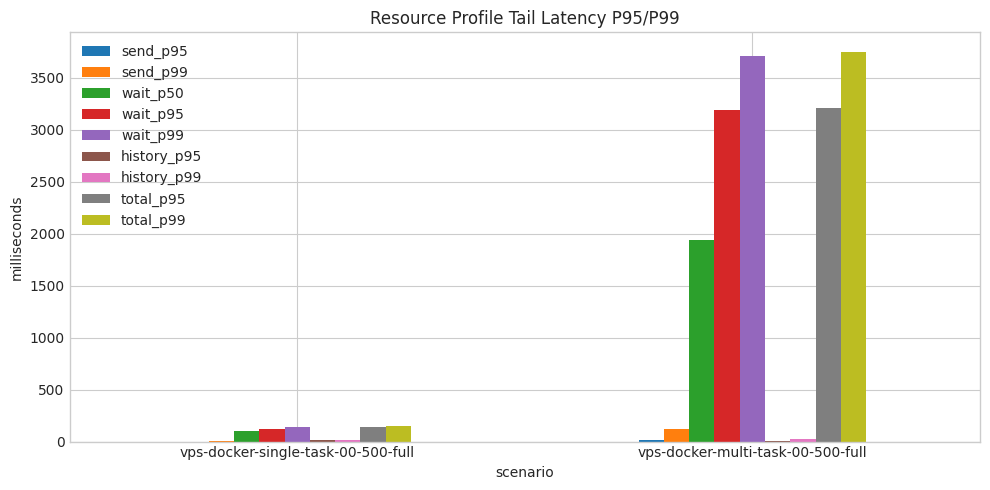

In [110]:
resource_tail_df = resource_profile_df[["send_p95_ms", "send_p99_ms", "wait_p50_ms", "wait_p95_ms", "wait_p99_ms", "history_p95_ms", "history_p99_ms", "total_p95_ms", "total_p99_ms"]].rename(columns={
    "send_p95_ms": "send_p95",
    "send_p99_ms": "send_p99",
    "wait_p50_ms": "wait_p50",
    "wait_p95_ms": "wait_p95",
    "wait_p99_ms": "wait_p99",
    "history_p95_ms": "history_p95",
    "history_p99_ms": "history_p99",
    "total_p95_ms": "total_p95",
    "total_p99_ms": "total_p99",
})
print(resource_tail_df.round(3))
ax = resource_tail_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Resource Profile Tail Latency P95/P99")
ax.set_ylabel("milliseconds")
plt.tight_layout()
plt.show()

                                    cpu_percent  mem_percent
scenario                                                    
vps-docker-single-task-00-500-full      104.185        4.138
vps-docker-multi-task-00-500-full       102.546        4.145


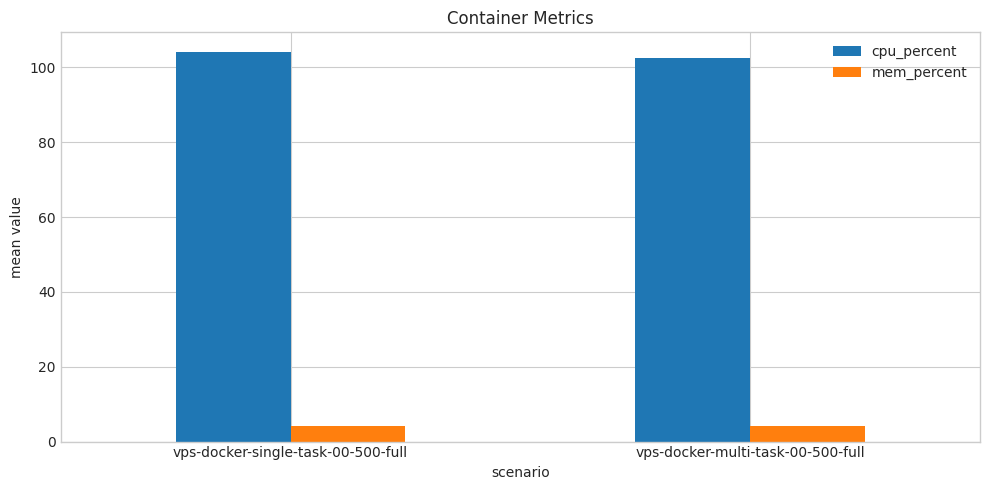

In [111]:
resource_container_df = resource_profile_df[[
    "docker_cpu_percent_mean",
    "docker_mem_percent_mean",
]].rename(columns={
    "docker_cpu_percent_mean": "cpu_percent",
    "docker_mem_percent_mean": "mem_percent",
})

print(resource_container_df.round(3))
ax = resource_container_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Container Metrics")
ax.set_ylabel("mean value")
plt.tight_layout()
plt.show()


In [112]:
resource_process_df = resource_profile_df[[
    "pidstat_cpu_percent_mean",
    "pidstat_rss_kib_mean",
    "pidstat_kb_wr_per_s_mean",
    "pidstat_iodelay_mean",
]].rename(columns={
    "pidstat_cpu_percent_mean": "cpu_percent",
    "pidstat_rss_kib_mean": "rss_kib",
    "pidstat_kb_wr_per_s_mean": "kb_wr_per_s",
    "pidstat_iodelay_mean": "iodelay",
})
resource_process_df.round(3)


,cpu_percent,rss_kib,kb_wr_per_s,iodelay
scenario,,,,
vps-docker-single-task-00-500-full,0.0,980.0,0.0,0.0
vps-docker-multi-task-00-500-full,0.0,980.0,0.0,0.0


In [113]:
resource_disk_df = resource_profile_df[[
    "iostat_busiest_device",
    "iostat_pct_util_mean",
    "iostat_r_await_mean",
    "iostat_w_await_mean",
    "iostat_aqu_sz_mean",
    "iostat_wkb_s_mean",
]].rename(columns={
    "iostat_busiest_device": "busiest_device",
    "iostat_pct_util_mean": "pct_util",
    "iostat_r_await_mean": "r_await",
    "iostat_w_await_mean": "w_await",
    "iostat_aqu_sz_mean": "aqu_sz",
    "iostat_wkb_s_mean": "wkb_s",
})

resource_disk_df.round(3)


,busiest_device,pct_util,r_await,w_await,aqu_sz,wkb_s
scenario,,,,,,
vps-docker-single-task-00-500-full,vda,0.810,0.0,1.027,0.025,819.661
vps-docker-multi-task-00-500-full,vda,0.947,0.0,1.018,0.021,734.994


## Semianalysis-100 Average

In [115]:
from pathlib import Path
import json
from copy import deepcopy


def find_run_dirs(scenario_name: str, last_n: int | None = None) -> list[Path]:
    candidates = sorted(
        [path for path in out_root.iterdir() if path.is_dir() and path.name.endswith(f"_{scenario_name}")],
        key=lambda path: path.name,
    )
    if not candidates:
        raise FileNotFoundError(f"No run directory found for scenario: {scenario_name}")
    if last_n is not None:
        candidates = candidates[-last_n:]
    return candidates


def load_summary(run_dir: str | Path) -> dict:
    run_dir = Path(run_dir)
    return json.loads((run_dir / "summary.json").read_text(encoding="utf-8"))


def load_summaries(scenario_name: str, last_n: int | None = None) -> list[dict]:
    run_dirs = find_run_dirs(scenario_name, last_n=last_n)
    return [load_summary(run_dir) for run_dir in run_dirs]


def average_summaries_keep_metadata(summaries: list[dict]) -> dict:
    if not summaries:
        raise ValueError("summaries is empty")

    result = deepcopy(summaries[-1])

    result["aggregated_from_runs"] = len(summaries)
    result["aggregated_run_dirs"] = [
        s.get("_run_dir") for s in summaries if s.get("_run_dir") is not None
    ]

    numeric_paths = [
        ("requests_total",),
        ("requests_ok",),
        ("requests_failed",),

        ("latency_ms", "connect", "mean"),
        ("latency_ms", "connect", "p50"),
        ("latency_ms", "connect", "p95"),
        ("latency_ms", "connect", "p99"),
        ("latency_ms", "connect", "min"),
        ("latency_ms", "connect", "max"),

        ("latency_ms", "send", "mean"),
        ("latency_ms", "send", "p50"),
        ("latency_ms", "send", "p95"),
        ("latency_ms", "send", "p99"),
        ("latency_ms", "send", "min"),
        ("latency_ms", "send", "max"),

        ("latency_ms", "wait", "mean"),
        ("latency_ms", "wait", "p50"),
        ("latency_ms", "wait", "p95"),
        ("latency_ms", "wait", "p99"),
        ("latency_ms", "wait", "min"),
        ("latency_ms", "wait", "max"),

        ("latency_ms", "history", "mean"),
        ("latency_ms", "history", "p50"),
        ("latency_ms", "history", "p95"),
        ("latency_ms", "history", "p99"),
        ("latency_ms", "history", "min"),
        ("latency_ms", "history", "max"),

        ("latency_ms", "total", "mean"),
        ("latency_ms", "total", "p50"),
        ("latency_ms", "total", "p95"),
        ("latency_ms", "total", "p99"),
        ("latency_ms", "total", "min"),
        ("latency_ms", "total", "max"),
    ]

    def get_path(d: dict, path: tuple[str, ...]):
        cur = d
        for key in path:
            if not isinstance(cur, dict) or key not in cur:
                return None
            cur = cur[key]
        return cur

    def set_path(d: dict, path: tuple[str, ...], value):
        cur = d
        for key in path[:-1]:
            cur = cur.setdefault(key, {})
        cur[path[-1]] = value

    for path in numeric_paths:
        values = []
        for summary in summaries:
            value = get_path(summary, path)
            if isinstance(value, (int, float)):
                values.append(value)
        if values:
            set_path(result, path, sum(values) / len(values))

    return result

def load_summaries(scenario_name: str, last_n: int | None = None) -> list[dict]:
    run_dirs = find_run_dirs(scenario_name, last_n=last_n)
    summaries = []
    for run_dir in run_dirs:
        summary = load_summary(run_dir)
        summary["_run_dir"] = str(run_dir)
        summaries.append(summary)
    return summaries

def nested_get(data: dict, path: list[str], default=None):
    current = data
    for key in path:
        if not isinstance(current, dict) or key not in current:
            return default
        current = current[key]
    return current


def metric_mean(data: dict, path: list[str], default=None):
    metric = nested_get(data, path, None)
    if isinstance(metric, dict):
        return metric.get("mean", default)
    return default


def metric_summary_mean(data: dict, path: list[str], default=None):
    metric = nested_get(data, path, None)
    if isinstance(metric, dict):
        summary = metric.get("summary")
        if isinstance(summary, dict):
            return summary.get("mean", default)
    return default


def build_semianalysis_100_row(summary: dict) -> dict:
    latency = summary["latency_ms"]
    task = summary.get("task", {})
    docker = nested_get(summary, ["collector_analysis", "docker_stats"], {})
    pidstat = nested_get(summary, ["collector_analysis", "pidstat", "sections"], {})
    iostat = nested_get(summary, ["collector_analysis", "iostat"], {})
    iostat_key = nested_get(summary, ["collector_analysis", "iostat", "key_metric_summaries"], {})
    busiest_device = nested_get(summary, ["collector_analysis", "iostat", "key_metrics", "busiest_device"]) or iostat.get("busiest_device_by_util_mean")
    device_metrics = nested_get(iostat, ["devices", busiest_device, "metrics"], {}) if busiest_device else {}
    return {
        "scenario": summary["scenario"],
        "task_id": task.get("id", ""),
        "task_name": task.get("name", ""),
        "requests_total": summary["requests_total"],
        "requests_ok": summary["requests_ok"],
        "requests_failed": summary["requests_failed"],
        "connect_mean_ms": latency["connect"]["mean"],
        "send_mean_ms": latency["send"]["mean"],
        "send_p95_ms": latency["send"]["p95"],
        "send_p99_ms": latency["send"]["p99"],
        "wait_mean_ms": latency["wait"]["mean"],
        "wait_p95_ms": latency["wait"]["p95"],
        "wait_p99_ms": latency["wait"]["p99"],
        "history_mean_ms": latency["history"]["mean"],
        "history_p95_ms": latency["history"]["p95"],
        "history_p99_ms": latency["history"]["p99"],
        "total_mean_ms": latency["total"]["mean"],
        "total_p50_ms": latency["total"]["p50"],
        "total_p95_ms": latency["total"]["p95"],
        "total_p99_ms": latency["total"]["p99"],
        "docker_cpu_percent_mean": metric_summary_mean(docker, ["metric_summaries", "cpu_percent_value"]),
        "docker_mem_percent_mean": metric_summary_mean(docker, ["metric_summaries", "mem_percent_value"]),
        "docker_block_read_bytes_per_s_mean": metric_summary_mean(docker, ["metric_summaries", "block_read_bytes_per_s"]),
        "docker_block_write_bytes_per_s_mean": metric_summary_mean(docker, ["metric_summaries", "block_write_bytes_per_s"]),
        "pidstat_cpu_percent_mean": metric_summary_mean(pidstat, ["cpu", "metric_summaries", "pct_cpu"]),
        "pidstat_rss_kib_mean": metric_summary_mean(pidstat, ["memory", "metric_summaries", "rss_kib"]),
        "pidstat_kb_wr_per_s_mean": metric_summary_mean(pidstat, ["io", "metric_summaries", "kb_wr_per_s"]),
        "pidstat_iodelay_mean": metric_summary_mean(pidstat, ["io", "metric_summaries", "iodelay"]),
        "iostat_busiest_device": busiest_device,
        "iostat_pct_util_mean": metric_summary_mean(iostat_key, ["pct_util"], metric_mean(device_metrics, ["pct_util"])),
        "iostat_r_await_mean": metric_summary_mean(iostat_key, ["r_await"], metric_mean(device_metrics, ["r_await"])),
        "iostat_w_await_mean": metric_summary_mean(iostat_key, ["w_await"], metric_mean(device_metrics, ["w_await"])),
        "iostat_aqu_sz_mean": metric_summary_mean(iostat_key, ["aqu_sz"], metric_mean(device_metrics, ["aqu_sz"])),
        "iostat_wkb_s_mean": metric_summary_mean(iostat_key, ["wkb_s"], metric_mean(device_metrics, ["wkb_s"])),
    }



In [138]:
single_semianalysis_100_summaries = load_summaries(
    "docker-single-task-semianalysis-100-summary",
    last_n=None,
)
multi_semianalysis_100_summaries = load_summaries(
    "docker-multi-task-semianalysis-100-summary",
    last_n=None,
)
print('Records Numbers:', len(single_semianalysis_100_summaries))
single_semianalysis_100_summary_avg = average_summaries_keep_metadata(single_semianalysis_100_summaries)
multi_semianalysis_100_summary_avg = average_summaries_keep_metadata(multi_semianalysis_100_summaries)

semianalysis_100_df_avg = pd.DataFrame([
    build_semianalysis_100_row(single_semianalysis_100_summary_avg),
    build_semianalysis_100_row(multi_semianalysis_100_summary_avg),
]).set_index("scenario")

semianalysis_100_df_avg.round(3).T


Records Numbers: 5


scenario,docker-single-task-semianalysis-100-summary,docker-multi-task-semianalysis-100-summary
task_id,task_05_semianalysis_title,task_05_semianalysis_title
task_name,Semianalysis Title Fetch,Semianalysis Title Fetch
requests_total,100.0,100.0
requests_ok,100.0,100.0
requests_failed,0.0,0.0
connect_mean_ms,201.451,162.405
send_mean_ms,0.998,2.569
send_p95_ms,1.412,2.716
send_p99_ms,2.15,44.11
wait_mean_ms,19.757,73.863


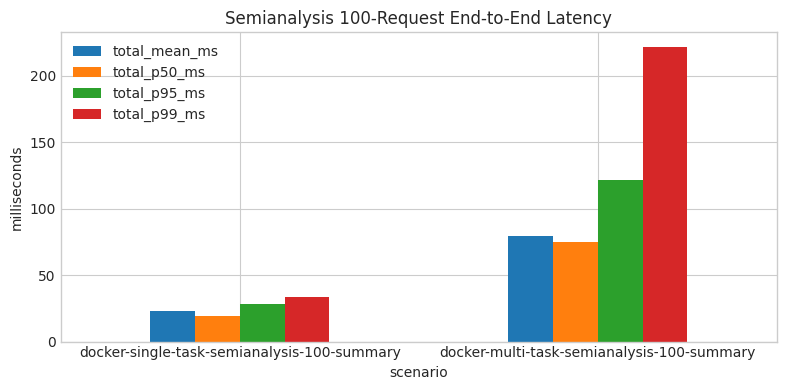

In [139]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(1, 1, figsize=(8, 4))

semianalysis_100_df_avg[["total_mean_ms", "total_p50_ms", "total_p95_ms", "total_p99_ms"]].plot(
    kind="bar",
    ax=axes,
    rot=0,
    title="Semianalysis 100-Request End-to-End Latency",
)
axes.set_ylabel("milliseconds")

plt.tight_layout()
plt.show()


In [140]:
semianalysis_100_phase_df = semianalysis_100_df_avg[[
    "connect_mean_ms",
    "send_mean_ms",
    "wait_mean_ms",
    "history_mean_ms",
    "total_mean_ms",
]].rename(columns={
    "connect_mean_ms": "connect",
    "send_mean_ms": "send",
    "wait_mean_ms": "wait",
    "history_mean_ms": "history",
    "total_mean_ms": "total",
})

semianalysis_100_phase_df.round(3)


,connect,send,wait,history,total
scenario,,,,,
docker-single-task-semianalysis-100-summary,201.451,0.998,19.757,2.085,22.876
docker-multi-task-semianalysis-100-summary,162.405,2.569,73.863,3.301,79.771


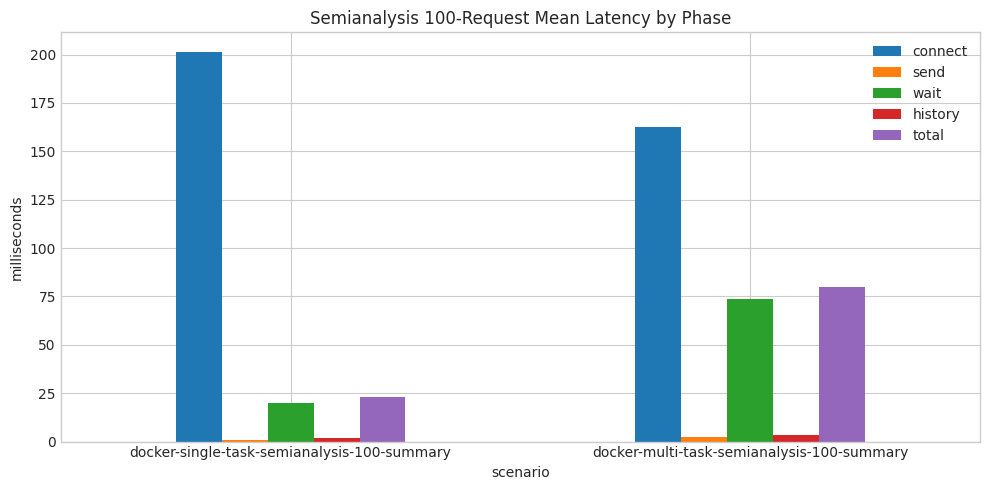

In [141]:
ax = semianalysis_100_phase_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Semianalysis 100-Request Mean Latency by Phase")
ax.set_ylabel("milliseconds")
plt.tight_layout()
plt.show()


In [142]:
semianalysis_100_tail_df = semianalysis_100_df_avg[["send_p95_ms", "send_p99_ms", "wait_p95_ms", "wait_p99_ms", "history_p95_ms", "history_p99_ms", "total_p95_ms", "total_p99_ms"]].rename(columns={
    "send_p95_ms": "send_p95",
    "send_p99_ms": "send_p99",
    "wait_p95_ms": "wait_p95",
    "wait_p99_ms": "wait_p99",
    "history_p95_ms": "history_p95",
    "history_p99_ms": "history_p99",
    "total_p95_ms": "total_p95",
    "total_p99_ms": "total_p99",
})

semianalysis_100_tail_df.round(3)


,send_p95,send_p99,wait_p95,wait_p99,history_p95,history_p99,total_p95,total_p99
scenario,,,,,,,,
docker-single-task-semianalysis-100-summary,1.412,2.15,24.857,29.628,3.217,8.188,28.127,33.825
docker-multi-task-semianalysis-100-summary,2.716,44.11,111.303,212.878,6.730,11.625,121.305,221.589


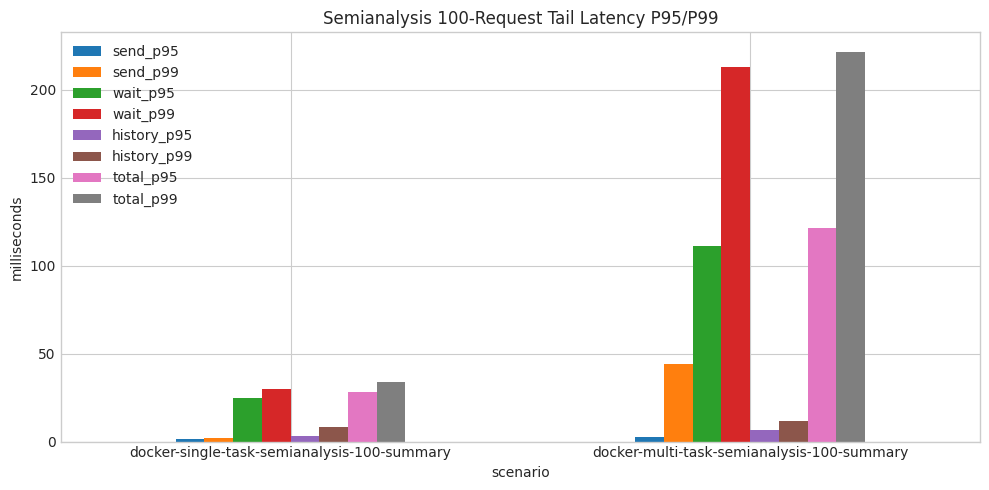

In [143]:
ax = semianalysis_100_tail_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Semianalysis 100-Request Tail Latency P95/P99")
ax.set_ylabel("milliseconds")
plt.tight_layout()
plt.show()


In [144]:
semianalysis_100_container_df = semianalysis_100_df_avg[[
    "docker_cpu_percent_mean",
    "docker_mem_percent_mean",
    # "docker_block_read_bytes_per_s_mean",
    # "docker_block_write_bytes_per_s_mean",
]].rename(columns={
    "docker_cpu_percent_mean": "cpu_percent",
    "docker_mem_percent_mean": "mem_percent",
    # "docker_block_read_bytes_per_s_mean": "block_read_bytes_per_s",
    # "docker_block_write_bytes_per_s_mean": "block_write_bytes_per_s",
})

semianalysis_100_container_df.round(3)


,cpu_percent,mem_percent
scenario,,
docker-single-task-semianalysis-100-summary,58.54,19.755
docker-multi-task-semianalysis-100-summary,66.67,20.965


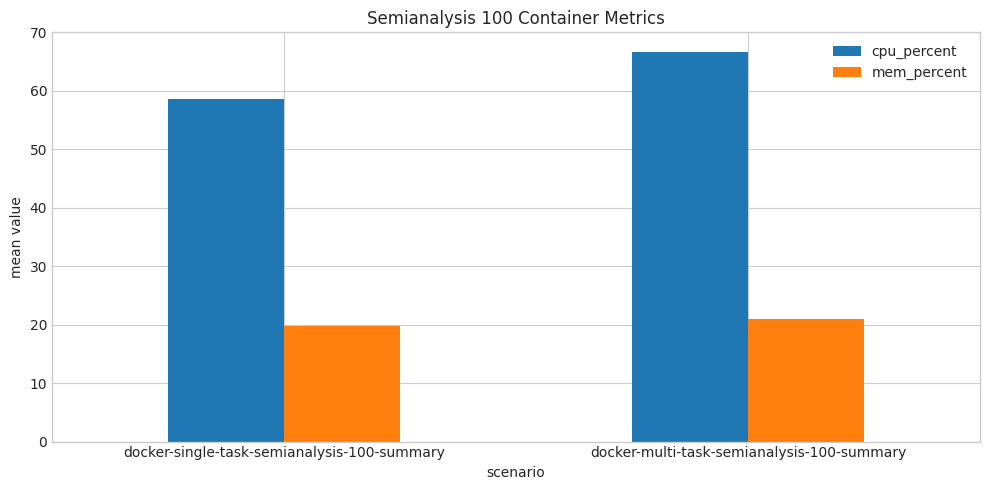

In [145]:
ax = semianalysis_100_container_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Semianalysis 100 Container Metrics")
ax.set_ylabel("mean value")
plt.tight_layout()
plt.show()


## 查看 `cache-miss` 和 `context switch`

下面这组单元直接从 `summary.json` 的 `collector_analysis.perf_stat` 和 `collector_analysis.pidstat` 里提取：

- `cache-misses`
- `cache-references`
- `cache_miss_rate`
- `perf context-switches`
- `pidstat cswch_per_s`
- `pidstat nvcswch_per_s`

如果某次运行没有这些值，通常说明该场景没有成功采到 `perf_stat`，例如本机 / WSL 上 `perf` 被跳过。

In [114]:
def build_cache_context_row(summary: dict) -> dict:
    perf_metric_summaries = nested_get(summary, ["collector_analysis", "perf_stat", "metric_summaries"], {})
    perf_key_metric_summaries = nested_get(summary, ["collector_analysis", "perf_stat", "key_metric_summaries"], {})
    pidstat_sections = nested_get(summary, ["collector_analysis", "pidstat", "sections"], {})

    cache_misses_mean = nested_get(perf_metric_summaries, ["cache-misses", "summary", "mean"])
    cache_references_mean = nested_get(perf_metric_summaries, ["cache-references", "summary", "mean"])
    perf_context_switches_mean = nested_get(perf_key_metric_summaries, ["context_switches", "summary", "mean"])
    pidstat_cswch_mean = metric_mean(pidstat_sections, ["context_switch", "metrics", "cswch_per_s"])
    pidstat_nvcswch_mean = metric_mean(pidstat_sections, ["context_switch", "metrics", "nvcswch_per_s"])

    cache_miss_rate = None
    if isinstance(cache_misses_mean, (int, float)) and isinstance(cache_references_mean, (int, float)) and cache_references_mean:
        cache_miss_rate = cache_misses_mean / cache_references_mean

    return {
        "scenario": summary.get("scenario", ""),
        "aggregated_from_runs": summary.get("aggregated_from_runs", 1),
        "cache_misses_mean": cache_misses_mean,
        "cache_references_mean": cache_references_mean,
        "cache_miss_rate": cache_miss_rate,
        "perf_context_switches_mean": perf_context_switches_mean,
        "pidstat_cswch_per_s_mean": pidstat_cswch_mean,
        "pidstat_nvcswch_per_s_mean": pidstat_nvcswch_mean,
    }

single_semianalysis_100_run_dir = find_latest_run_dir("vps-docker-single-task-00-500-full")
multi_semianalysis_100_run_dir = find_latest_run_dir("vps-docker-multi-task-00-500-full")

single_semianalysis_100_summary = load_summary(single_semianalysis_100_run_dir)
multi_semianalysis_100_summary = load_summary(multi_semianalysis_100_run_dir)

cache_context_df = pd.DataFrame([
    build_cache_context_row(single_semianalysis_100_summary),
    build_cache_context_row(multi_semianalysis_100_summary),
]).set_index("scenario")

cache_context_df.round(6).T

scenario,vps-docker-single-task-00-500-full,vps-docker-multi-task-00-500-full
aggregated_from_runs,1,1
cache_misses_mean,None,None
cache_references_mean,None,None
cache_miss_rate,None,None
perf_context_switches_mean,69.127333,66.976185
pidstat_cswch_per_s_mean,0.0,0.0
pidstat_nvcswch_per_s_mean,1.0,1.0


## Task-00-500

In [115]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

# out_root = Path("/root/client-harness/out")

# def find_latest_run_dir(scenario_name: str) -> Path:
#     candidates = sorted(
#         [path for path in out_root.iterdir() if path.is_dir() and path.name.endswith(f"_{scenario_name}")],
#         key=lambda path: path.name,
#     )
#     if not candidates:
#         raise FileNotFoundError(f"No run directory found for scenario: {scenario_name}")
#     return candidates[-1]


# def load_summary(run_dir: Path) -> dict:
#     return json.loads((run_dir / "summary.json").read_text(encoding="utf-8"))


single_run_dir = find_latest_run_dir("vps-docker-single-task-00-500-full")
multi_run_dir = find_latest_run_dir("vps-docker-multi-task-00-500-full")

single_summary = load_summary(single_run_dir)
multi_summary = load_summary(multi_run_dir)

single_run_dir, multi_run_dir


(PosixPath('/root/client-harness/out/20260324T183523Z_vps-docker-single-task-00-500-full'),
 PosixPath('/root/client-harness/out/20260324T183647Z_vps-docker-multi-task-00-500-full'))

In [116]:
single_summary["scenario"], multi_summary["scenario"]

('vps-docker-single-task-00-500-full', 'vps-docker-multi-task-00-500-full')

In [117]:
def nested_get(data: dict, path: list[str], default=None):
    current = data
    for key in path:
        if not isinstance(current, dict) or key not in current:
            return default
        current = current[key]
    return current

def metric_mean(data: dict, path: list[str], default=None):
    metric = nested_get(data, path, None)
    if isinstance(metric, dict):
        return metric.get("mean", default)
    return default

def metric_summary_mean(data: dict, path: list[str], default=None):
    metric = nested_get(data, path, None)
    if isinstance(metric, dict):
        summary = metric.get("summary")
        if isinstance(summary, dict):
            return summary.get("mean", default)
    return default

def build_resource_profile_row(summary: dict) -> dict:
    latency = summary["latency_ms"]
    docker = nested_get(summary, ["collector_analysis", "docker_stats"], {})
    pidstat = nested_get(summary, ["collector_analysis", "pidstat", "sections"], {})
    iostat = nested_get(summary, ["collector_analysis", "iostat"], {})
    iostat_key = nested_get(summary, ["collector_analysis", "iostat", "key_metric_summaries"], {})
    busiest_device = nested_get(summary, ["collector_analysis", "iostat", "key_metrics", "busiest_device"]) or iostat.get("busiest_device_by_util_mean")
    device_metrics = nested_get(iostat, ["devices", busiest_device, "metrics"], {}) if busiest_device else {}
    return {
        "scenario": summary["scenario"],
        "requests_total": summary["requests_total"],
        "requests_ok": summary["requests_ok"],
        "requests_failed": summary["requests_failed"],
        "connect_mean_ms": latency["connect"]["mean"],
        "send_mean_ms": latency["send"]["mean"],
        "send_p95_ms": latency["send"]["p95"],
        "send_p99_ms": latency["send"]["p99"],
        "wait_mean_ms": latency["wait"]["mean"],
        "wait_p50_ms": latency["wait"]["p50"],
        "wait_p95_ms": latency["wait"]["p95"],
        "wait_p99_ms": latency["wait"]["p99"],
        "wait_p95_ms": latency["wait"]["p95"],
        "wait_p99_ms": latency["wait"]["p99"],
        "history_mean_ms": latency["history"]["mean"],
        "history_p95_ms": latency["history"]["p95"],
        "history_p99_ms": latency["history"]["p99"],
        "total_mean_ms": latency["total"]["mean"],
        "total_p50_ms": latency["total"]["p50"],
        "total_p95_ms": latency["total"]["p95"],
        "total_p99_ms": latency["total"]["p99"],
        "docker_cpu_percent_mean": metric_summary_mean(docker, ["metric_summaries", "cpu_percent_value"]),
        "docker_mem_percent_mean": metric_summary_mean(docker, ["metric_summaries", "mem_percent_value"]),
        "docker_block_read_bytes_per_s_mean": metric_summary_mean(docker, ["metric_summaries", "block_read_bytes_per_s"]),
        "docker_block_write_bytes_per_s_mean": metric_summary_mean(docker, ["metric_summaries", "block_write_bytes_per_s"]),
        "pidstat_cpu_percent_mean": metric_summary_mean(pidstat, ["cpu", "metric_summaries", "pct_cpu"]),
        "pidstat_rss_kib_mean": metric_summary_mean(pidstat, ["memory", "metric_summaries", "rss_kib"]),
        "pidstat_kb_wr_per_s_mean": metric_summary_mean(pidstat, ["io", "metric_summaries", "kb_wr_per_s"]),
        "pidstat_iodelay_mean": metric_summary_mean(pidstat, ["io", "metric_summaries", "iodelay"]),
        "iostat_busiest_device": busiest_device,
        "iostat_pct_util_mean": metric_summary_mean(iostat_key, ["pct_util"], metric_mean(device_metrics, ["pct_util"])),
        "iostat_r_await_mean": metric_summary_mean(iostat_key, ["r_await"], metric_mean(device_metrics, ["r_await"])),
        "iostat_w_await_mean": metric_summary_mean(iostat_key, ["w_await"], metric_mean(device_metrics, ["w_await"])),
        "iostat_aqu_sz_mean": metric_summary_mean(iostat_key, ["aqu_sz"], metric_mean(device_metrics, ["aqu_sz"])),
        "iostat_wkb_s_mean": metric_summary_mean(iostat_key, ["wkb_s"], metric_mean(device_metrics, ["wkb_s"])),
    }

resource_profile_df = pd.DataFrame([
    build_resource_profile_row(single_summary),
    build_resource_profile_row(multi_summary),
]).set_index("scenario")
resource_profile_df.round(3).T

scenario,vps-docker-single-task-00-500-full,vps-docker-multi-task-00-500-full
requests_total,500,500
requests_ok,500,500
requests_failed,0,0
connect_mean_ms,67.011,389.055
send_mean_ms,0.72,4.914
send_p95_ms,0.734,11.813
send_p99_ms,4.602,122.814
wait_mean_ms,105.016,1989.45
wait_p50_ms,100.739,1937.666
wait_p95_ms,124.863,3190.944


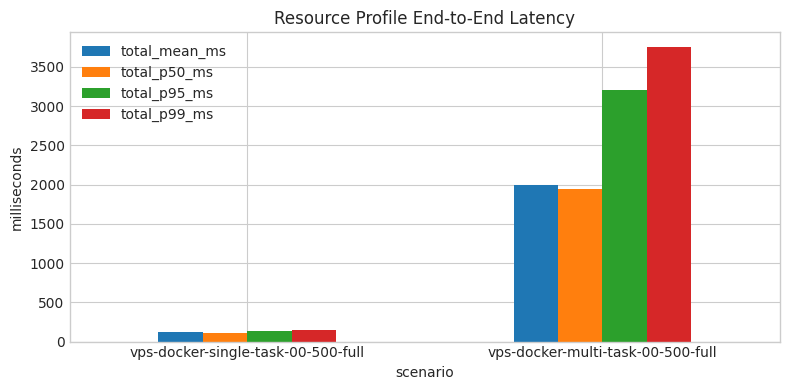

In [118]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(1, 1, figsize=(8, 4))

resource_profile_df[["total_mean_ms", "total_p50_ms", "total_p95_ms", "total_p99_ms"]].plot(
    kind="bar",
    ax=axes,
    rot=0,
    title="Resource Profile End-to-End Latency",
)
axes.set_ylabel("milliseconds")

plt.tight_layout()
plt.show()


In [119]:
resource_phase_df = resource_profile_df[[
    "connect_mean_ms",
    "send_mean_ms",
    "wait_mean_ms",
    "history_mean_ms",
    "total_mean_ms",
]].rename(columns={
    "connect_mean_ms": "connect",
    "send_mean_ms": "send",
    "wait_mean_ms": "wait",
    "history_mean_ms": "history",
    "total_mean_ms": "total",
})

resource_phase_df.round(3)


,connect,send,wait,history,total
scenario,,,,,
vps-docker-single-task-00-500-full,67.011,0.720,105.016,12.188,117.949
vps-docker-multi-task-00-500-full,389.055,4.914,1989.450,5.980,2000.369


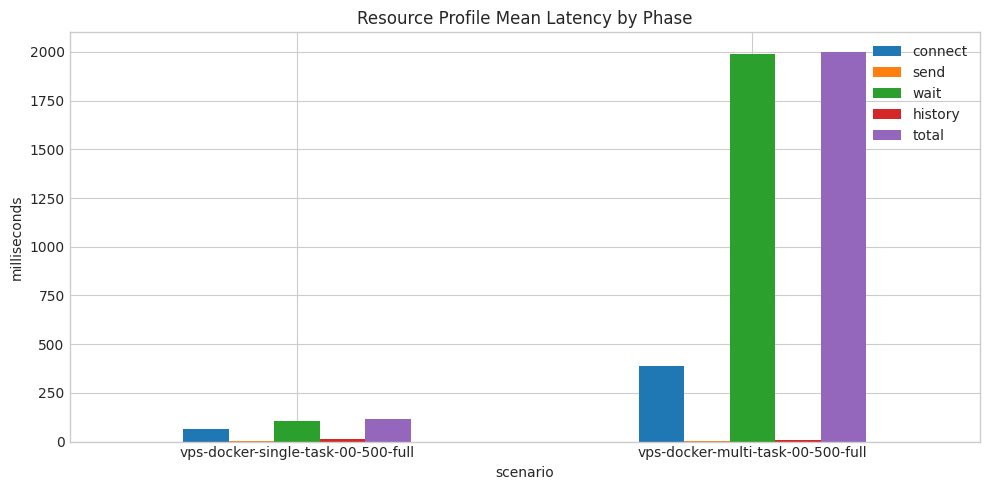

In [126]:
ax = resource_phase_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Resource Profile Mean Latency by Phase")
ax.set_ylabel("milliseconds")
plt.tight_layout()
plt.show()

                                    send_p95  send_p99  wait_p50  wait_p95  \
scenario                                                                     
vps-docker-single-task-00-500-full     0.734     4.602   100.739   124.863   
vps-docker-multi-task-00-500-full     11.813   122.814  1937.666  3190.944   

                                    wait_p99  history_p95  history_p99  \
scenario                                                                 
vps-docker-single-task-00-500-full   139.965       13.991       15.075   
vps-docker-multi-task-00-500-full   3713.961       10.093       22.291   

                                    total_p95  total_p99  
scenario                                                  
vps-docker-single-task-00-500-full    138.049    149.266  
vps-docker-multi-task-00-500-full    3206.884   3750.755  


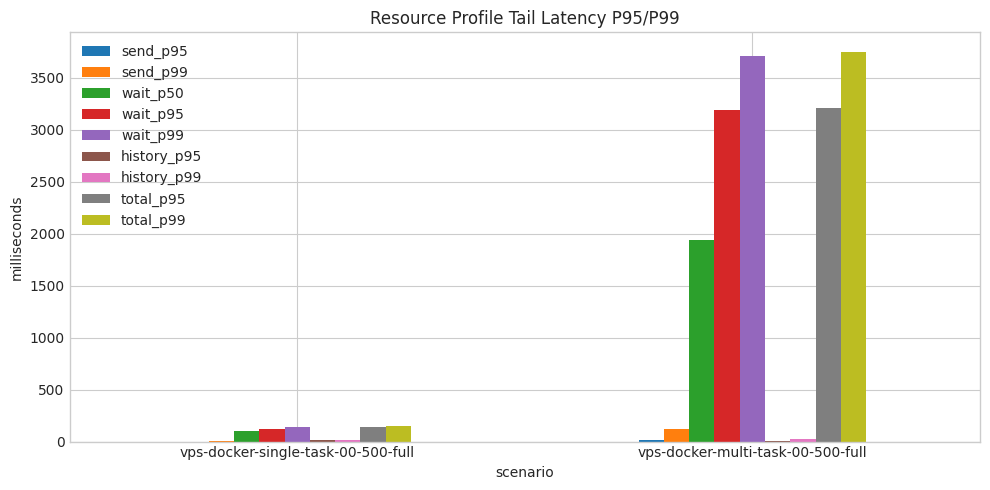

In [127]:
resource_tail_df = resource_profile_df[["send_p95_ms", "send_p99_ms", "wait_p50_ms", "wait_p95_ms", "wait_p99_ms", "history_p95_ms", "history_p99_ms", "total_p95_ms", "total_p99_ms"]].rename(columns={
    "send_p95_ms": "send_p95",
    "send_p99_ms": "send_p99",
    "wait_p50_ms": "wait_p50",
    "wait_p95_ms": "wait_p95",
    "wait_p99_ms": "wait_p99",
    "history_p95_ms": "history_p95",
    "history_p99_ms": "history_p99",
    "total_p95_ms": "total_p95",
    "total_p99_ms": "total_p99",
})
print(resource_tail_df.round(3))
ax = resource_tail_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Resource Profile Tail Latency P95/P99")
ax.set_ylabel("milliseconds")
plt.tight_layout()
plt.show()

                                    cpu_percent  mem_percent
scenario                                                    
vps-docker-single-task-00-500-full      104.185        4.138
vps-docker-multi-task-00-500-full       102.546        4.145


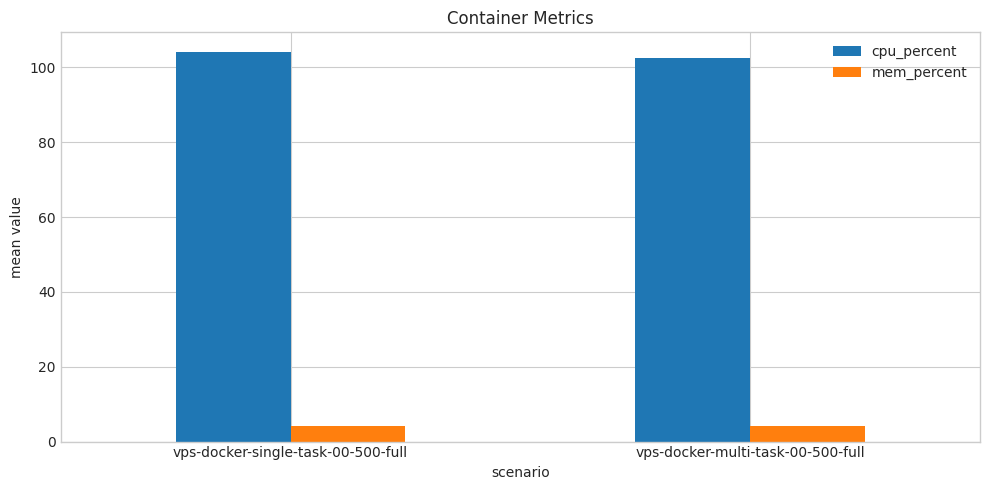

In [128]:
resource_container_df = resource_profile_df[[
    "docker_cpu_percent_mean",
    "docker_mem_percent_mean",
]].rename(columns={
    "docker_cpu_percent_mean": "cpu_percent",
    "docker_mem_percent_mean": "mem_percent",
})

print(resource_container_df.round(3))
ax = resource_container_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Container Metrics")
ax.set_ylabel("mean value")
plt.tight_layout()
plt.show()

                                    block_read_bytes_per_s  \
scenario                                                     
vps-docker-single-task-00-500-full                     0.0   
vps-docker-multi-task-00-500-full                      0.0   

                                    block_write_bytes_per_s  
scenario                                                     
vps-docker-single-task-00-500-full                34999.779  
vps-docker-multi-task-00-500-full                118635.584  


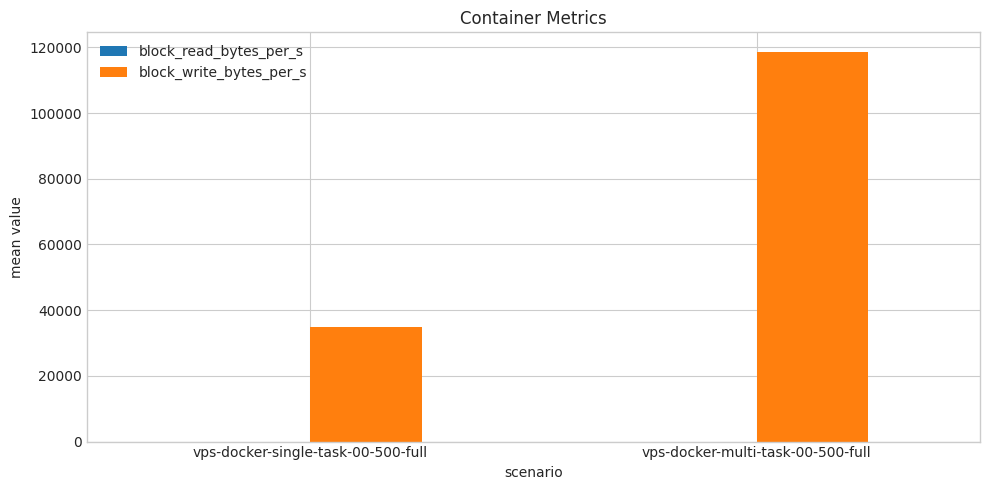

In [129]:
resource_container_df = resource_profile_df[[
    "docker_block_read_bytes_per_s_mean",
    "docker_block_write_bytes_per_s_mean",
]].rename(columns={
    "docker_block_read_bytes_per_s_mean": "block_read_bytes_per_s",
    "docker_block_write_bytes_per_s_mean": "block_write_bytes_per_s",
})

print(resource_container_df.round(3))
ax = resource_container_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Container Metrics")
ax.set_ylabel("mean value")
plt.tight_layout()
plt.show()


In [130]:
resource_process_df = resource_profile_df[[
    "pidstat_cpu_percent_mean",
    "pidstat_rss_kib_mean",
    "pidstat_kb_wr_per_s_mean",
    "pidstat_iodelay_mean",
]].rename(columns={
    "pidstat_cpu_percent_mean": "cpu_percent",
    "pidstat_rss_kib_mean": "rss_kib",
    "pidstat_kb_wr_per_s_mean": "kb_wr_per_s",
    "pidstat_iodelay_mean": "iodelay",
})

resource_process_df.round(3)


,cpu_percent,rss_kib,kb_wr_per_s,iodelay
scenario,,,,
vps-docker-single-task-00-500-full,0.0,980.0,0.0,0.0
vps-docker-multi-task-00-500-full,0.0,980.0,0.0,0.0


In [131]:
resource_disk_df = resource_profile_df[[
    "iostat_busiest_device",
    "iostat_pct_util_mean",
    "iostat_r_await_mean",
    "iostat_w_await_mean",
    "iostat_aqu_sz_mean",
    "iostat_wkb_s_mean",
]].rename(columns={
    "iostat_busiest_device": "busiest_device",
    "iostat_pct_util_mean": "pct_util",
    "iostat_r_await_mean": "r_await",
    "iostat_w_await_mean": "w_await",
    "iostat_aqu_sz_mean": "aqu_sz",
    "iostat_wkb_s_mean": "wkb_s",
})

resource_disk_df.round(3)


,busiest_device,pct_util,r_await,w_await,aqu_sz,wkb_s
scenario,,,,,,
vps-docker-single-task-00-500-full,vda,0.810,0.0,1.027,0.025,819.661
vps-docker-multi-task-00-500-full,vda,0.947,0.0,1.018,0.021,734.994


- `pct_util`
  - 设备忙碌率，表示这块磁盘有多少时间处于“忙着处理 I/O”的状态。
  - 越接近 `100%`，说明磁盘越接近打满。
- `r_await`
  - 读请求的平均等待时间，单位通常是毫秒。
  - 包含排队时间 + 设备实际处理时间。
- `w_await`
  - 写请求的平均等待时间，单位通常是毫秒。
  - 包含排队时间 + 设备实际处理时间。
- `f_await`
  - flush 请求的平均等待时间，单位通常是毫秒。
  - 常见于落盘、刷缓存到稳定存储的路径。
- `aqu_sz`
  - 平均队列长度。
  - 可以理解成“同时在等磁盘处理的 I/O 大概有多少个”。
- `wkb_s`
  - 每秒写入磁盘的千字节数。
  - 也就是写吞吐，`write KB/s`。

如果你把它们一起看，常见解读是：

- `wkb_s` 上升，但 `pct_util` 还不高，说明写流量在变大，但磁盘还没完全忙起来。
- `w_await` 和 `aqu_sz` 也上升，说明写请求开始排队了。
- `pct_util` 接近 `100%`，说明磁盘已经很忙，后续请求更容易被拖慢。

## Latency per Request

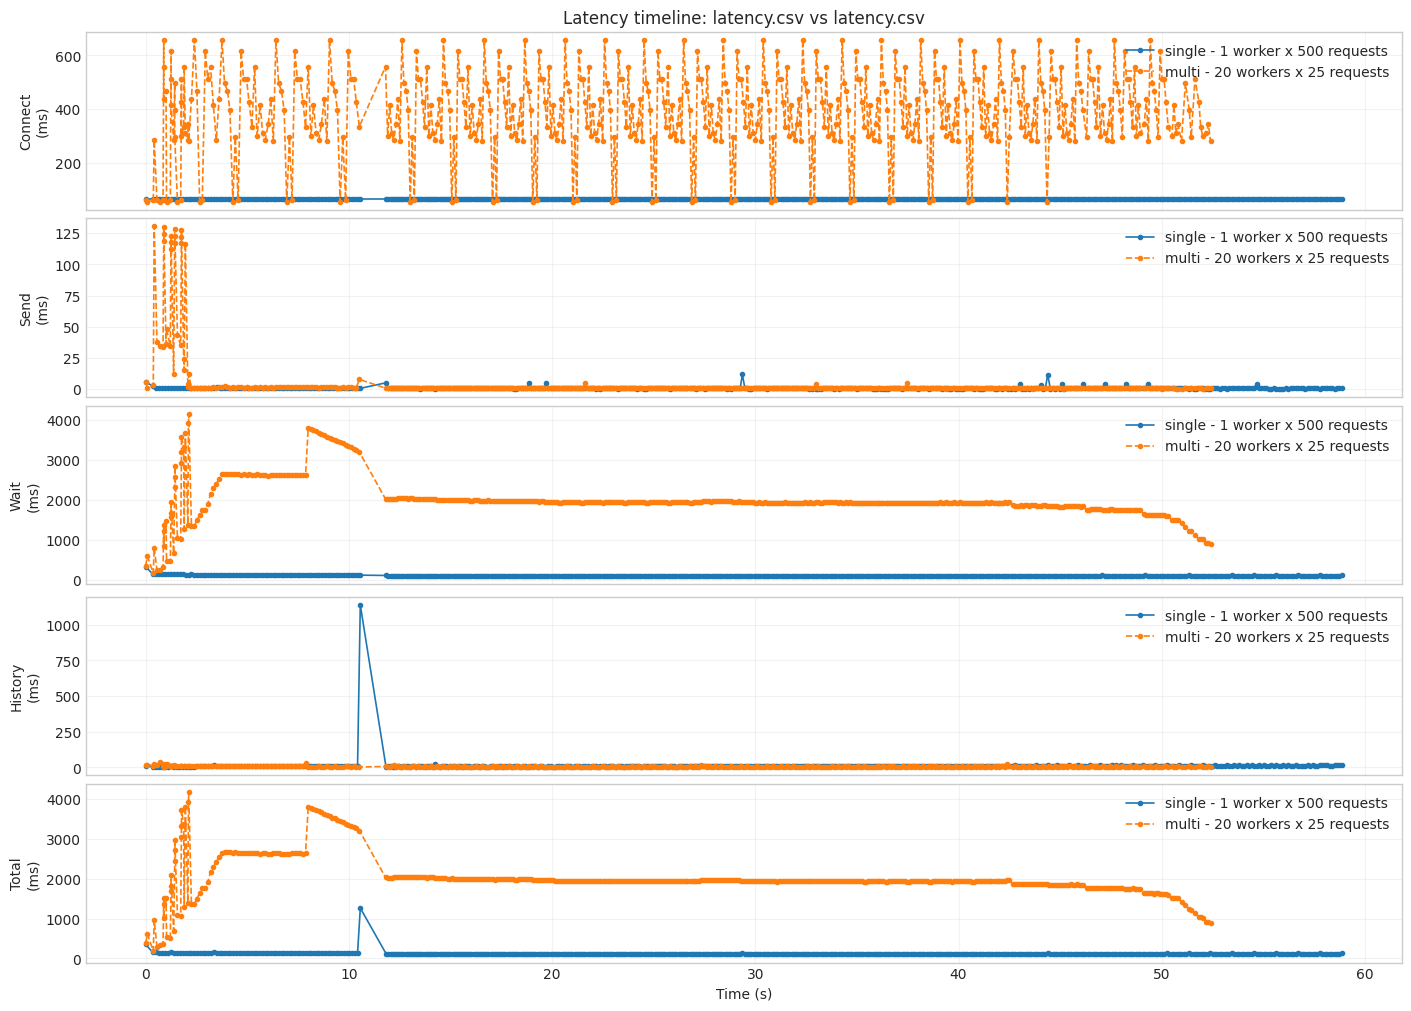

In [132]:
# %matplotlib inline
from pathlib import Path
import sys
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("scripts").resolve()))

from plot_latency import load_points, LATENCY_COLUMNS


def show_latency_timeline(path_a, path_b, label_a="A", label_b="B"):
    csv_path_a = Path(path_a)
    csv_path_b = Path(path_b)

    points_a = load_points(csv_path_a, only_success=False)
    points_b = load_points(csv_path_b, only_success=False)

    # x_a = [p.started_at for p in points_a]
    # x_b = [p.started_at for p in points_b]
    t0_a = points_a[0].started_at
    t0_b = points_b[0].started_at

    x_a = [(p.started_at - t0_a).total_seconds() for p in points_a]
    x_b = [(p.started_at - t0_b).total_seconds() for p in points_b]
    fig, axes = plt.subplots(
        len(LATENCY_COLUMNS),
        1,
        sharex=True,
        figsize=(14, 10),
        constrained_layout=True,
    )

    if len(LATENCY_COLUMNS) == 1:
        axes = [axes]

    # ❗去掉 strict=True，避免潜在报错
    for ax, (column, label) in zip(axes, LATENCY_COLUMNS):
        y_a = [p.values.get(column) for p in points_a]
        y_b = [p.values.get(column) for p in points_b]

        # ✅ 第一组
        ax.plot(
            x_a, y_a,
            marker="o",
            markersize=3,
            linewidth=1.2,
            label=label_a,
        )

        # ✅ 第二组
        ax.plot(
            x_b, y_b,
            marker="o",
            markersize=3,
            linewidth=1.2,
            linestyle="--",
            label=label_b,
        )

        ax.set_ylabel(f"{label}\n(ms)")
        ax.grid(True, alpha=0.25)

        # ✅ 每个子图都有图例（或者你也可以只放第一个）
        ax.legend()

    axes[-1].set_xlabel("Time (s)")
    axes[0].set_title(
        f"Latency timeline: {csv_path_a.name} vs {csv_path_b.name}"
    )

    plt.show()

show_latency_timeline(
    "./out/20260324T183523Z_vps-docker-single-task-00-500-full/latency.csv",
    "./out/20260324T183647Z_vps-docker-multi-task-00-500-full/latency.csv",
    label_a="single - 1 worker x 500 requests",
    label_b="multi - 20 workers x 25 requests"
)

In [ ]:
show_latency_timeline(
    "./out/20260324T183523Z_vps-docker-single-task-00-500-full/latency.csv",
    "./out/20260324T183647Z_vps-docker-multi-task-00-500-full/latency.csv",
    label_a="single - 1 worker x 500 requests",
    label_b="multi - 20 workers x 25 requests"
)